# Creating a sample of M stars between 50 and 200pc

Benjamin Pennell

--

Max Planck Institut für Astronomie, Heidelberg

---

In [1]:
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pickle
import h5py
import matplotlib
import pandas as pd

from astropy.table import Table
from astroquery.gaia import Gaia
from utils.style import *

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
def print_table(table, label=None):
    rates = [len(table[table["solution_type"] == soltype])/len(table)*100 for soltype in [0,5,7,9,12]]
    grid = [
        rates,
        [int(grp/100*len(table)) for grp in rates]
    ]
    row_labels = ["Rate (%)", "Counts"]
    col_labels = ["low RUWE", "high RUWE", "Acceleration", "Jerk", "Full Orbit"]
    df = pd.DataFrame(grid, index=row_labels, columns=col_labels)
    displaydf = df.style.format(
        "{:.0f}",
        subset=pd.IndexSlice["Counts", :]
    ).format(
        "{:.2f}",
        subset=pd.IndexSlice["Rate (%)", :]
    )
    
    if label is not None:
        displaydf.set_caption(label)
    
    display(displaydf)

## Select objects

In [3]:
msms = h5py.File("../../BigData/msms_36m_v0.hdf5", "r")

In [4]:
msms["table"]["columns"].keys()

<KeysViewHDF5 ['E_binary', 'E_single', 'MG_prim', 'MG_second', 'b_r_prim', 'b_r_second', 'bp_rp', 'chi2_diff_mh_mass', 'chi2_mass_mh', 'chi2_mass_mh_binary', 'dec', 'e_E_binary', 'e_E_single', 'e_m1_binary', 'e_mass_single', 'e_mh_binary', 'e_mh_single', 'e_q_binary', 'fit_status_binary', 'fit_status_single', 'fit_success_binary', 'fit_success_single', 'flag_extrap_m2', 'flux_ratio_mean', 'flux_ratio_std', 'm1_binary', 'm2_binary', 'mass_single', 'mh_binary', 'mh_single', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'predicted_class', 'q_binary', 'ra', 'radial_velocity', 'radial_velocity_error', 'source_id']>

In [21]:
new_table = Table()

In [22]:
labels = ["source_id", "parallax", "ra", "dec", "phot_g_mean_mag", "mass_single", "m1_binary", "m2_binary", "predicted_class", "bp_rp", "mh_single", "q_binary", "flux_ratio_mean", "chi2_mass_mh", "chi2_mass_mh_binary", "chi2_diff_mh_mass", "fit_success_single", "fit_success_binary"]
for label in labels:
    new_table.add_column(np.array(msms["table"]["columns"][label]["data"]), name=label)

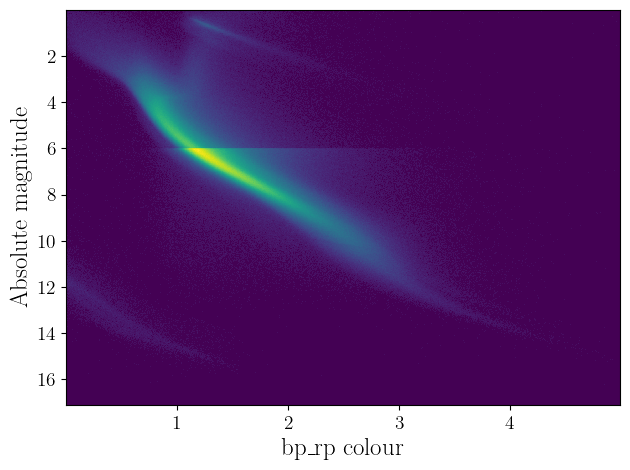

In [7]:
bp_rp = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

plt.hist2d(bp_rp, absolute_magnitudes, bins=1000, norm=matplotlib.colors.PowerNorm(0.4));
plt.ylabel("Absolute magnitude");
plt.xlabel("bp_rp colour");
plt.ylim(bottom=np.max(absolute_magnitudes), top=np.min(absolute_magnitudes));
plt.xlim([np.min(bp_rp), np.max(bp_rp)]);
plt.tight_layout()

trim to objects in our mass and parallax range which had the single and binary star fits

note: only 7 objects didn't have a successful single or binary star fit

In [23]:
PARALLAX_MASK = (new_table["parallax"] < 20) & (new_table["parallax"] > 5) # 50-200pc
MASS_MASK = (new_table["mass_single"] < 0.4) & (new_table["mass_single"] > 0.2)
ARBITRARY_CUT = new_table["bp_rp"] > 2
SUCCESS_CUT = (new_table["fit_success_binary"]) & (new_table["fit_success_single"])
total_mask = PARALLAX_MASK & MASS_MASK & ARBITRARY_CUT & SUCCESS_CUT
working_table = new_table[total_mask]

## Pull solution type, binary properties from gaia

In [27]:
job = Gaia.launch_job_async("""SELECT *
                                FROM gaiadr3.nss_two_body_orbit AS g
                                WHERE g.parallax > 5
                                AND g.parallax < 20
                                """)

nss_table = job.get_results()

job = Gaia.launch_job_async("""SELECT *
                                FROM gaiadr3.nss_acceleration_astro AS g
                                WHERE g.parallax > 5
                                AND g.parallax < 20
                                """)

accel_table = job.get_results()

INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]


In [28]:
# a test
job = Gaia.launch_job_async(r"""select pmra, pmdec, ruwe
                        from gaiadr3.gaia_source 
                        where source_id = 5478926884285078784""")
results = job.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [29]:
import os
os.environ["XDG_CACHE_HOME"] = os.path.expanduser("~/.astroquery_tmp")

In [30]:
def chunk_list(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 10000  # Gaia can usually handle 50-100 IDs per query

all_results = []

for batch in tqdm(list(chunk_list(working_table["source_id"], batch_size))):
    ids_str = ",".join(str(sid) for sid in batch)
    query = f"""
    SELECT source_id, pmra, pmdec, ruwe
    FROM gaiadr3.gaia_source
    WHERE source_id IN ({ids_str})
    """
    job = Gaia.launch_job_async(query, verbose=False)
    results = job.get_results()
    all_results.append(results.to_pandas())

df = pd.concat(all_results, ignore_index=True)

  0%|          | 0/43 [00:00<?, ?it/s]

INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]


In [31]:
working_table.add_column(np.zeros(len(working_table)), name="pmra")
working_table.add_column(np.zeros(len(working_table)), name="pmdec")
working_table.add_column(np.zeros(len(working_table)), name="ruwe")
working_table.add_column(np.zeros(len(working_table)), name="solution_type")
working_table.add_column(np.zeros(len(working_table)), name="period")
working_table.add_column(np.zeros(len(working_table)), name="eccentricity")

In [32]:
mask = np.isin(working_table["source_id"], df["source_id"])  # boolean mask for rows to update
data_indices = np.where(mask)[0]

# Step 2: Map update indices
update_map = {sid: i for i, sid in enumerate(df['source_id'])}

# Step 3: Update only the desired columns
for col in ['pmra', 'pmdec', 'ruwe']: #, 'period', 'eccentricity']:
    # Pick corresponding values from updates_df
    working_table[col][data_indices] = [df[col][update_map[sid]] for sid in working_table['source_id'][data_indices]]

In [ ]:
accel_ids = list(accel_table["source_id"])
nss_ids = list(nss_table["source_id"])

for row in tqdm(working_table):
    if row["ruwe"] < 1.4:
        row["solution_type"] = int(0)
    elif row["source_id"] in nss_ids:
        row["solution_type"] = int(12)
    elif row["source_id"] in accel_ids:
        if accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration7":
            row["solution_type"] = int(7)
        elif accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration9":
            row["solution_type"] = int(9)
    else:
        row["solution_type"] = int(5)

  0%|          | 0/421032 [00:00<?, ?it/s]

In [34]:
working_table.write('../data/all_mdwarfs_200pc.fits', format='fits', overwrite=True)

## Trim objects based on some mindful criteria

In [3]:
working_table = Table.read('./data/all_mdwarfs_200pc.fits', format='fits')

In [4]:
print_table(working_table, label="All objects")

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),93.48,5.98,0.27,0.12,0.15
Counts,393566,25156,1146,520,643


We need to determine a good flux ratio cutoff, perhpas we can do this by calling gaiamock a whole bunch and seeing where RUWE stars to meaningfully change

In [5]:
import utils.GaiamockWrapperLite as gw

In [33]:
ra, dec = 25, 25
c_funcs = gw.generate_cfuncs()
t, t_mod = gw.generate_scanning_times(ra, dec)

qs = np.linspace(0.1,0.5,10)
fs = np.logspace(-3,-0.3,100)

ruwes = np.zeros((len(qs), len(fs)))
for i, q in enumerate(qs):
    for j, f in enumerate(fs):
        _, ruwe = gw.rapid_solution_type(800, q, 8, 0.3, 17, f, 0.2, np.pi/4, 0, 0, 0.25, ra, dec, 5, 5, t=t, t_mod=t_mod, skip_full=True, return_ruwe=True, c_funcs=c_funcs)
        ruwes[i,j] = ruwe

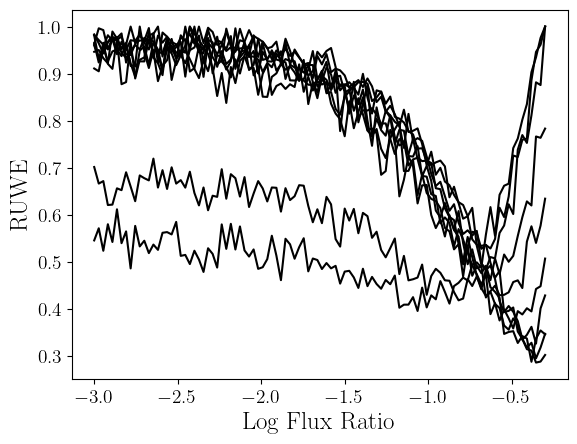

In [34]:
for i in range(len(qs)):
    plt.plot(np.log10(fs), ruwes[i]/np.max(ruwes[i]));
plt.xlabel("Log Flux Ratio");
plt.ylabel("RUWE");

In [19]:
len(working_table[working_table["chi2_diff_mh_mass"] > 0]), len(working_table[working_table["predicted_class"] != 0]), len(working_table)

(271091, 112294, 421032)

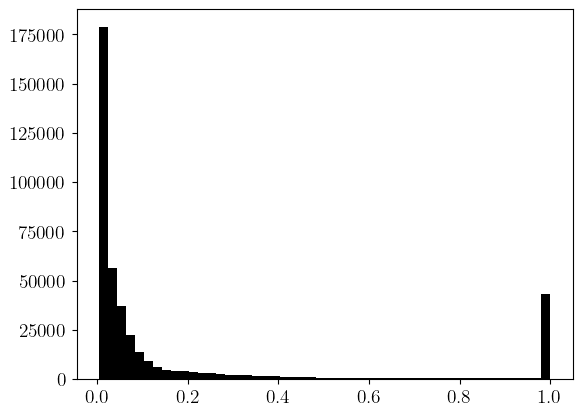

In [ ]:
plt.hist(working_table["flux_ratio_mean"], bins=50);

In [42]:
print_table(working_table[working_table["predicted_class"] == 0], label="Predicted Class 0")
print_table(working_table[working_table["predicted_class"] != 0], label="Predicted Class NOT 0")
LUM_CUT = working_table["flux_ratio_mean"] < 10**(-1)
Q_CUT = working_table["q_binary"] < 0.6
RESTRICTED_MASK = LUM_CUT & Q_CUT
SINGLE_MASK = working_table["predicted_class"] == 0
print_table(working_table[RESTRICTED_MASK], label="flux ratio < 0.1")
SINGLE_MASK = working_table["predicted_class"] == 0
print_table(working_table[RESTRICTED_MASK & SINGLE_MASK], label="low flux ratios + effectively single")

LUM_CUT = working_table["flux_ratio_mean"] < 10**(-1.5)
Q_CUT = working_table["q_binary"] < 0.6
RESTRICTED_MASK = LUM_CUT & Q_CUT
print_table(working_table[RESTRICTED_MASK], label="flux ratio < ~0.03")
SINGLE_MASK = working_table["predicted_class"] == 0
print_table(working_table[RESTRICTED_MASK & SINGLE_MASK], label="low flux ratios + effectively single")

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),94.85,4.84,0.16,0.06,0.09
Counts,292828,14937,492,192,287


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),89.71,9.10,0.58,0.29,0.32
Counts,100738,10220,654,327,355


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),94.92,4.54,0.26,0.13,0.16
Counts,291268,13928,799,384,483


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.59,4.10,0.16,0.06,0.09
Counts,259367,11113,447,171,245


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.54,4.13,0.15,0.07,0.10
Counts,193769,8381,313,151,203


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.67,4.02,0.15,0.06,0.09
Counts,189872,7984,296,127,178


We want to select a complete sample of binaries, it's fine if it's not pure. We then want to hand-wave show that the effectively single star objects 

In [ ]:
len(working_table), len(test_table)

(421032, 364828)

In [ ]:
SINGLE_MASK = working_table["predicted_class"] == 0
LUM_CUT = working_table["flux_ratio_mean"] < 0.1
Q_CUT = working_table["q_binary"] < 0.6

In [ ]:
all_in_range = new_table[PARALLAX_MASK & MASS_MASK & ARBITRARY_CUT]
print(len(all_in_range))
rejected = new_table[PARALLAX_MASK & MASS_MASK & ARBITRARY_CUT & ( (np.invert(SINGLE_MASK)) | (SINGLE_MASK & np.invert(LUM_CUT)) )]
print(len(rejected))

421039
149690


In [ ]:
len(new_table[total_mask]), len(new_table[total_mask & LUM_CUT]), len(new_table[total_mask & Q_CUT]), len(new_table[total_mask & LUM_CUT & Q_CUT])

(308744, 271349, 286205, 271349)